# Binary Classification - No Hypoxia (Normal) or Mild Hypoxia (Suspicious)

For the initial experiments, a binary classification task was defined to distinguish normal CTG recordings from mildly hypoxic (suspicious) recordings. Records labelled as “No Hypoxia (Normal)” were assigned to class 0, while records labelled as “Mild Hypoxia (Suspicious)” were assigned to class 1. This setting focuses on subtle pattern differences rather than overt pathological changes.

This binary classification experiment derives from Expert Annotation data, provided within the original dataset: 
PhysioNet link to dataset - https://physionet.org/content/ctu-uhb-ctgdb/1.0.0/

Paper describing the dataset - https://bmcpregnancychildbirth.biomedcentral.com/track/pdf/10.1186/1471-2393-14-16.pdf

Link to expert evaluation as described in Hruban et al. 2015 - http://people.ciirc.cvut.cz/~spilkjir/data.html

Expert evaluation of the CTG data "Gold Standard" evaluation based on annotation of the signals by 9 expert obstetricians (following FIGO guidelines used in the Czech Republic) including variability/confidence for each signal

## Custom Model for Binary Classification
This part of the project aims to get initial results by asking this question: 
"Given a full CTG record (FHR signal), can we predict whether the fetus ever showed signs of mild hypoxia?"

| Challenge                               | Strategy                                                                 |
|----------------------------------------|--------------------------------------------------------------------------|
| CTG recordings are very long (hours)   | Break long FHR signals into shorter, fixed-length windows                |
| Hypoxia events are episodic            | Use window-based analysis to capture local abnormal patterns              |
| Labels are record-level, not moment-level | Aggregate window-level predictions into a single record-level decision |
| FHR signals are noisy and non-stationary | Use CNNs to learn robust local temporal patterns automatically           |

This model uses **1D Residual Convolutional Neural Network**, which designed for time-series and local temporal dependencies. 

### Residual Block: 
Residual block is a neural-network building unit that learns changes instead of learning the entire signal from scratch. Residual block were invented because of some issues such as vanishing gradient problem and the degradation problem. residual blocks solved this by stabling gradient and with the easy information flow, which led to ResNet (We will be using the pre-Trained ResNet in the next notebook)

x → Conv → BN → ReLU → Conv → BN

|________________________|

            +
            
BN: Batch Normalisation
ReLu: Rectified Linear Unit (Activation function) - this keeps positive values and kills negatives. 

"+" is an element-wise addition between the input and the transformed signal, allowing network to learn residual correction rather than the full mapping. This preserves baseline information and stabilises the training and prevents vanishing gradient problem. 

### Layer by Layer Model Architecture: 
Input: (4800 samples, 1 channel)
Initial Conv Block: Conv1D(64 filters, kernel 7), Batch Normalisation, ReLu. This is to capture basic heart rate patterns. 
Residual Block 1: 64 filters. Conv → Conv → Add → Pool. This is to capture low-level temporal features. 
Residual Block 2: 128 Filters, for mid-level patterns like accelerations or decelerations. 
Residual Block 3: 256 filters , Higher level abstraction. 
Flatten(): preserve the remporaş structure 
Total Depth: ~10 convolutional layers and 1 fully connected classifier

In 3 residual blocks:
| Block   | Filters | Shortcut Conv needed? |
| ------- | ------- | --------------------- |
| Block 1 | 64      | No (64 → 64)        |
| Block 2 | 128     | Yes (64 → 128)      |
| Block 3 | 256     | Yes (128 → 256)     |

Block 1: 2 convs

Block 2: 3 convs
Block 3: 3 convs 

total from residual blocks = 8 conv layers.
Then;

(Initial Conv: 1 conv) + (Residual Blocks = 8 conv) = 9 Convo1D layers.

### Record Level Evaluation
Records are what the labels mean. This model does not trust window predictions only. This answers şf the CTG contain hypoxic episodes at any time during the record, which matches the clinical reality and label definition. 





In [23]:
# Necessary imports 
import pandas as pd 
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix,  precision_recall_curve, auc
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

In [3]:
'''
Load and prepare labels
'''
labels_df = pd.read_csv("../ExpertAnnotations/CTG_Majority_Vote_Labels_FINAL.csv")
labels_df["binary_label"] = labels_df["Majority_Vote_Label"].map({1: 0, 2: 1})
labels_df = labels_df.dropna(subset=["binary_label"])



In [4]:
'''
Signal Windowing: 
As CNNs require fixed-length input and they are local and temporal, we segment CTG signals into overlapping windows.
These windows helps learn subtle differences in CTG patterns.

Parameters:
Sampling rate: 4 Hz
Window length: 20 minutes
Window size: 20 * 60 * 4 = 4800 samples 20 60 2 = 2400 
Stride: 5 minutes (overlap helps)
'''

FS = 4
WINDOW_MIN = 20
STRIDE_MIN = 5

WINDOW_SIZE = WINDOW_MIN * 60 * FS
STRIDE = STRIDE_MIN * 60 * FS

In [5]:
'''
Window Extraction Function
is _informative_window: filters out uninformative windows based on std and amplitude range
normalize_window: standardizes windows to zero mean and unit variance
'''
def extract_windows(signal, window_size, stride):
    return np.array([
        signal[i:i + window_size]
        for i in range(0, len(signal) - window_size + 1, stride)
    ])

def is_informative_window(w):
    return (
        np.std(w) > 5 and
        (np.max(w) - np.min(w)) > 15
    )

def normalize_window(w):
    return (w - np.mean(w)) / (np.std(w) + 1e-6)


In [6]:
'''
Load FHR Signals from Cleaned CSVs
'''
FHR_DIR = Path("../cleaned_data/clean_csv")

def load_fhr_signal(rec_id):
    path = FHR_DIR / f"{rec_id}.csv"
    if not path.exists():
        return None
    return pd.read_csv(path).values.squeeze()


In [7]:
'''
Extract Windows and Prepare Dataset 
For each record, load FHR signal, extract windows, filter informative ones, normalize, and store with labels.
'''

X, y, rec_ids = [], [], []

for _, row in labels_df.iterrows():
    rec_id = row["rec_id"]
    label = row["binary_label"]

    signal = load_fhr_signal(rec_id)
    if signal is None:
        continue

    windows = extract_windows(signal, WINDOW_SIZE, STRIDE)

    for w in windows:
        if not is_informative_window(w):
            continue
        X.append(normalize_window(w))
        y.append(label)
        rec_ids.append(rec_id)

X = np.array(X)
y = np.array(y)
rec_ids = np.array(rec_ids)

print("Total informative windows:", X.shape[0])

Total informative windows: 4882


In [8]:
'''
Train-Val Split at Record Level:
Split by record, not by window, to avoid data leakage.
'''
unique_recs = np.unique(rec_ids)

train_recs, val_recs = train_test_split(
    unique_recs,
    test_size=0.2,
    stratify=[
        labels_df.loc[labels_df.rec_id == r, "binary_label"].values[0]
        for r in unique_recs
    ]
)

train_mask = np.isin(rec_ids, train_recs)
val_mask = np.isin(rec_ids, val_recs)

X_train, y_train, rec_train = X[train_mask], y[train_mask], rec_ids[train_mask]
X_val, y_val, rec_val = X[val_mask], y[val_mask], rec_ids[val_mask]

In [9]:
# Debugging

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"Class distribution - Train: {np.bincount(y_train)}")
print(f"Class distribution - Val: {np.bincount(y_val)}")

X_train shape: (3885, 4800)
X_val shape: (997, 4800)
Class distribution - Train: [3031  854]
Class distribution - Val: [759 238]


In [10]:
'''Calculate Class Weights to Handle the class Imbalance'''
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_actual = {0: weights[0], 1: weights[1]}
class_weight_dict = {0: 1.0, 1: 4.2} # Manually set for debugging
print("Class weights:", class_weight_actual)
print("Agressive class weigting:", class_weight_dict)


Class weights: {0: 0.640877598152425, 1: 2.2745901639344264}
Agressive class weigting: {0: 1.0, 1: 4.2}


In [11]:
'''
Build the Model
'''
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv1D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv1D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return layers.MaxPooling1D(2)(x)


inputs = layers.Input(shape=(WINDOW_SIZE, 1))
x = layers.Conv1D(64, 7, padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = residual_block(x, 64)
x = residual_block(x, 128)
x = residual_block(x, 256)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.BinaryAccuracy(name="accuracy")]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4800, 64)  │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4800, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4800, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 4800, 64)  │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4800, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4800, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4800, 64)  │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4800, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4800, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 4800, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 2400, 64)  │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2400, 128) │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2400, 128) │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2400, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2400, 128) │     49,280 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2400, 128) │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2400, 128) │      8,320 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2400, 128) │          0 │ batch_normalizat

 Total params: 20,100,865 (76.68 MB)

 Trainable params: 20,098,945 (76.67 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
'''
Train the Model
'''
model.fit(
    X_train[..., np.newaxis],
    y_train,
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    validation_data=(X_val[..., np.newaxis], y_val),
    
    callbacks=[
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        min_delta=0.001,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max'
    )
]
)

Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.4564 - auc: 0.5533 - loss: 1.6702 - val_accuracy: 0.2387 - val_auc: 0.4991 - val_loss: 0.7137 - learning_rate: 1.0000e-04
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 115s 939ms/step - accuracy: 0.5452 - auc: 0.6258 - loss: 1.1383 - val_accuracy: 0.2387 - val_auc: 0.4639 - val_loss: 0.8256 - learning_rate: 1.0000e-04
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 119s 975ms/step - accuracy: 0.5838 - auc: 0.6882 - loss: 1.0730 - val_accuracy: 0.2447 - val_auc: 0.5985 - val_loss: 0.7958 - learning_rate: 1.0000e-04
Epoch 4/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 115s 940ms/step - accuracy: 0.6458 - auc: 0.7495 - loss: 1.0047 - val_accuracy: 0.3039 - val_auc: 0.6464 - val_loss: 0.8916 - learning_rate: 1.0000e-04
Epoch 5/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7287 - auc: 0.8447 - loss: 0.8497 - val_accuracy: 0.5717 - val_auc: 0.6832 - val_loss: 0.7042 - learning_rate: 1.0000e-04
Epoch 6/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 136s 1

In [13]:
''' 
Evaluate the model on validation set
'''
val_preds = model.predict(X_val[..., np.newaxis]).squeeze()

record_scores = {}
for score, rid in zip(val_preds, rec_val):
    record_scores.setdefault(rid, []).append(score)

y_true_rec = []
y_pred_rec = []

for rid, scores in record_scores.items():
    y_pred_rec.append(np.mean(scores))
    y_true_rec.append(
        labels_df.loc[labels_df.rec_id == rid, "binary_label"].values[0]
    )

auc = roc_auc_score(y_true_rec, y_pred_rec)
print("Record-level AUC:", auc)

print(classification_report(
    y_true_rec,
    (np.array(y_pred_rec) > 0.5).astype(int)
))
conf_matrix = confusion_matrix(
    y_true_rec,
    (np.array(y_pred_rec) > 0.5).astype(int)
)


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step
Record-level AUC: 0.7948235294117647
              precision    recall  f1-score   support

           0       0.88      0.87      0.88        85
           1       0.58      0.60      0.59        25

    accuracy                           0.81       110
   macro avg       0.73      0.74      0.73       110
weighted avg       0.81      0.81      0.81       110



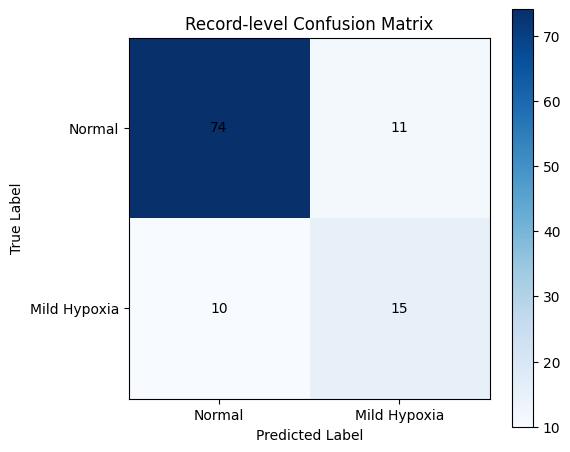


Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      0.87      0.88        85
Mild Hypoxia       0.58      0.60      0.59        25

    accuracy                           0.81       110
   macro avg       0.73      0.74      0.73       110
weighted avg       0.81      0.81      0.81       110



In [28]:
'''
Human readable classificastion report 
and Confusion Matrix
'''

# Convert probabilities to binary predictions
y_pred_binary = (np.array(y_pred_rec) > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true_rec, y_pred_binary)

labels = ["Normal", "Mild Hypoxia"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Record-level Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# To show the numbers inside the squares
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


print("\nClassification Report:")
print(classification_report(y_true_rec, y_pred_binary, target_names=["Normal", "Mild Hypoxia"]))


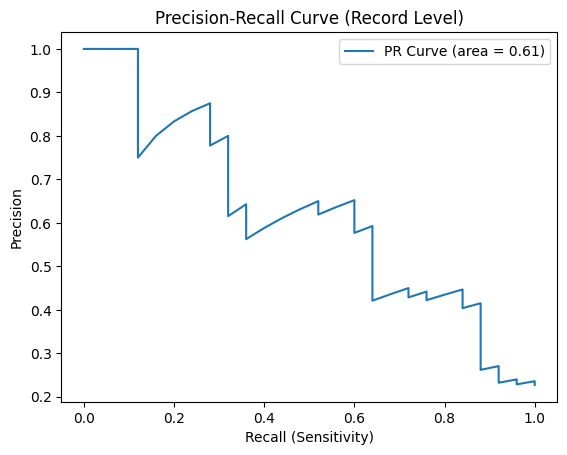

In [24]:
'''
Plot Precision-Recall Curve (Record Level)
This is helpful for imbalanced datasets because accuracy is often misleadingin clinical datasets.
'''
precision, recall, _ = precision_recall_curve(y_true_rec, y_pred_rec)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR Curve (area = {pr_auc:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Record Level)')
plt.legend()
plt.show()

## Performance Overview
The model is performing significantly better than a random classifier, achieving accuracy is 81%, the more telling metrics are found in the class-specific breakdown and the PR curve. In clinical tasks, AUC is much more insightful and important then accuracy because it evaluates the model's ability to discriminate between classes across all possible decision thresholds, rather than just at a single fixed point.

### Key Strengths
**High Specificity for Normal Records**: The model is excellent at identifying healthy fetuses, with a Recall (Sensitivity) of 87% for the Normal class.

**Balanced Macro-Averages**: A macro-average F1-score of 0.73 indicates that the model has learned meaningful features for both classes despite the inherent data imbalance.

**Effective Class Weighting**: The usage of class_weight_dict successfully pushed the Recall for Mild Hypoxia to 60%, which is much higher than typical baseline models that often ignore the minority class entirely. I used aggressive class weighting. While the majority class is around 3.5 times more, I gave the weigting of 4.2 to give more importance to minority class. 

### Areas for Clinical Consideration
**Precision**: For the "Mild Hypoxia" class, the precision is 0.58. This means that when the model flags a record as suspicious, it is correct about 58% of the time. In a clinical setting, this represents a moderate rate of false positives. This is open for improvement and not ready for a clinical setting. 

**The PR Curve (Area = 0.61)**: The PR curve shows a sharp drop-off after about 30% Recall. This suggests that while the model is very confident about some hypoxic patterns, it struggles to maintain high precision as it tries to catch the more subtle "Mild Hypoxia" cases.

#### Confusion Matrix Insight:

10 False Negatives: 10 hypoxic records were missed.

11 False Positives: 11 normal records were flagged.

For a "Mild Hypoxia" (Suspicious) task, these numbers are quite balanced, but usually, clinicians prefer higher recall even at the cost of more false positives.

So in short, The model is learning useful signal, but it is **not clinically reliable yet**.